# Notebook 05:Comparaison des modèles avec et sans « transfer »

Ce notebook compare fidèlement les résultats produits par :

- **Notebook 03** : modèle complet avec le terme `transfer` dans le texte TF-IDF ;
- **Notebook 04** : modèle réentraîné après retrait du terme `transfer` du texte TF-IDF.

Il ne réentraîne pas les modèles. Il reprend les métriques sauvegardées par les notebooks 03 et 04 afin d'éviter toute modification des calculs initiaux.

Ordre recommandé d'exécution :

1. `01_Construction_Cohorte_EDA.ipynb`
2. `02_Pretraitement_NLP.ipynb`
3. `03_Modele_avec_transfer.ipynb`
4. `04_Modele_sans_transfer.ipynb`
5. `ce notebook de comparaison`


## 1. Configuration

In [1]:
from pathlib import Path
import json
import math
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

RANDOM_STATE = 42
TARGET = "target"

#  Chemins projet — bloc unifié, identique dans NB01 -> NB08
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"
for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

#print("Dossier data      :", BASE.resolve())
#print("Dossier résultats :", RESULT_DIR.resolve())
#print("Dossier figures   :", FIG_DIR.resolve())


## 2. Vérification des fichiers nécessaires

In [2]:
fichiers_attendus = {
    "avec_transfer_test_interne": RESULT_DIR / "metrics_meilleur_modele.csv",
    "avec_transfer_validation_temporelle": RESULT_DIR / "metrics_validation_temporelle.csv",
    "sans_transfer_test_interne": RESULT_DIR / "metrics_meilleur_modele_sans_transfer.csv",
    "sans_transfer_validation_temporelle": RESULT_DIR / "metrics_validation_temporelle_sans_transfer.csv",
}

for nom, chemin in fichiers_attendus.items():
    statut = "OK" if chemin.exists() else "MANQUANT"
    print(f"{nom:<45} : {statut}")

manquants = [nom for nom, chemin in fichiers_attendus.items() if not chemin.exists()]
if manquants:
    raise FileNotFoundError(
        "Fichiers de métriques manquants : " + ", ".join(manquants) + "\n"
        "Exécuter d'abord les notebooks 03 et 04 dans l'ordre."
    )

# Fichiers nécessaires uniquement pour les courbes ROC.
# Ils sont vérifiés plus loin dans la section ROC afin de ne pas bloquer
# la comparaison tabulaire si la sauvegarde des prédictions individuelles
# n'a pas encore été exécutée.
fichiers_roc = {
    "predictions_avec_transfer": RESULT_DIR / "predictions_individuelles_avec_transfer.csv",
    "predictions_sans_transfer": RESULT_DIR / "predictions_individuelles_sans_transfer.csv",
}

#print("\nFichiers ROC individuels :")
for nom, chemin in fichiers_roc.items():
    statut = "OK" if chemin.exists() else "MANQUANT"
    print(f"{nom:<45} : {statut}")

avec_transfer_test_interne                    : OK
avec_transfer_validation_temporelle           : OK
sans_transfer_test_interne                    : OK
sans_transfer_validation_temporelle           : OK
predictions_avec_transfer                     : OK
predictions_sans_transfer                     : OK


## 3. Fonctions de normalisation des métriques

Les notebooks 03 et 04 n'utilisent pas exactement les mêmes libellés de colonnes. Cette section harmonise uniquement les noms pour permettre une comparaison propre, sans changer les valeurs.

In [3]:
def normaliser_jeu(x):
    """Harmonise les libellés de jeux d'évaluation."""
    if pd.isna(x):
        return x
    s = str(x).strip().lower().replace("_", " ")
    if "test" in s and "interne" in s:
        return "Test interne"
    if "validation" in s and "temp" in s:
        return "Validation temporelle"
    if "validation" in s and "interne" in s:
        return "Validation interne"
    return str(x)


def normaliser_seuil(x):
    """Harmonise les libellés de seuil."""
    if pd.isna(x):
        return x
    s = str(x).strip().lower()
    if "standard" in s or "0.5" in s or "0,5" in s:
        return "standard_0.5"
    if "clinique" in s or "alerte" in s or "sensibilite" in s or "se_90" in s:
        return "seuil_alerte_Se90"
    if "fort" in s:
        return "seuil_fort"
    return str(x)


def preparer_metrics(df, modele, source):
    """Prépare une table de métriques sans modifier les valeurs numériques."""
    out = df.copy()

    # Harmonisation des noms de colonnes.
    if "Seuil_type" in out.columns and "Type_seuil" not in out.columns:
        out = out.rename(columns={"Seuil_type": "Type_seuil"})
    if "Modele_retenu" in out.columns and "Modele_source" not in out.columns:
        out = out.rename(columns={"Modele_retenu": "Modele_source"})
    if "Modele" in out.columns and "Modele_source" not in out.columns:
        out = out.rename(columns={"Modele": "Modele_source"})

    if "Jeu" not in out.columns:
        # Le fichier metrics_validation_temporelle.csv du NB03 ne contient que la validation temporelle.
        if "validation_temporelle" in source:
            out["Jeu"] = "Validation temporelle"
        else:
            out["Jeu"] = "Non précisé"

    if "Type_seuil" not in out.columns:
        out["Type_seuil"] = "Non précisé"

    out["Modele_comparaison"] = modele
    out["Source"] = source
    out["Jeu_standardise"] = out["Jeu"].map(normaliser_jeu)
    out["Seuil_standardise"] = out["Type_seuil"].map(normaliser_seuil)

    # Conversion numérique sécurisée.
    colonnes_num = [
        "Seuil", "AUC", "Brier", "Se", "Sp", "VPP", "VPN",
        "VP", "VN", "FP", "FN", "Balanced_Accuracy", "FP/100", "FN/100"
    ]
    for col in colonnes_num:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Balanced accuracy si absente.
    if "Balanced_Accuracy" not in out.columns and {"Se", "Sp"}.issubset(out.columns):
        out["Balanced_Accuracy"] = (out["Se"] + out["Sp"]) / 2

    # FP/100 et FN/100 si absents et si les effectifs permettent le calcul.
    if "FP/100" not in out.columns and {"FP", "FN", "VP", "VN"}.issubset(out.columns):
        n = out[["FP", "FN", "VP", "VN"]].sum(axis=1)
        out["FP/100"] = np.where(n > 0, out["FP"] / n * 100, np.nan)
    if "FN/100" not in out.columns and {"FP", "FN", "VP", "VN"}.issubset(out.columns):
        n = out[["FP", "FN", "VP", "VN"]].sum(axis=1)
        out["FN/100"] = np.where(n > 0, out["FN"] / n * 100, np.nan)

    return out

print("Fonctions prêtes.")

Fonctions prêtes.


## 4. Chargement fidèle des résultats des notebooks 03 et 04

In [4]:
# Résultats du modèle AVEC transfer.
metrics_avec_test = pd.read_csv(RESULT_DIR / "metrics_meilleur_modele.csv")
metrics_avec_temp = pd.read_csv(RESULT_DIR / "metrics_validation_temporelle.csv")

metrics_avec = pd.concat([
    preparer_metrics(metrics_avec_test, "Avec transfer", "NB03_metrics_meilleur_modele.csv"),
    preparer_metrics(metrics_avec_temp, "Avec transfer", "NB03_metrics_validation_temporelle.csv"),
], ignore_index=True)

# Résultats du modèle SANS transfer.
# NB04 sauvegarde deux fichiers distincts, comme NB03 :
# - test interne : metrics_meilleur_modele_sans_transfer.csv
# - validation temporelle : metrics_validation_temporelle_sans_transfer.csv
metrics_sans_test = pd.read_csv(RESULT_DIR / "metrics_meilleur_modele_sans_transfer.csv")
metrics_sans_temp = pd.read_csv(RESULT_DIR / "metrics_validation_temporelle_sans_transfer.csv")

metrics_sans = pd.concat([
    preparer_metrics(metrics_sans_test, "Sans transfer", "NB04_metrics_meilleur_modele_sans_transfer.csv"),
    preparer_metrics(metrics_sans_temp, "Sans transfer", "NB04_metrics_validation_temporelle_sans_transfer.csv"),
], ignore_index=True)

comparaison_brute = pd.concat([metrics_avec, metrics_sans], ignore_index=True)

cols_affichage = [
    "Modele_comparaison", "Jeu_standardise", "Seuil_standardise", "Seuil",
    "AUC", "Brier", "Se", "Sp", "VPP", "VPN", "Balanced_Accuracy",
    "VP", "VN", "FP", "FN", "FP/100", "FN/100", "Source"
]
cols_affichage = [c for c in cols_affichage if c in comparaison_brute.columns]

comparaison_brute[cols_affichage].sort_values(
    ["Jeu_standardise", "Seuil_standardise", "Modele_comparaison"]
).round(4)

,Modele_comparaison,Jeu_standardise,Seuil_standardise,Seuil,AUC,Brier,Se,Sp,VPP,VPN,Balanced_Accuracy,VP,VN,FP,FN,FP/100,FN/100,Source
1,Avec transfer,Test interne,se_clin_90_val,0.241,0.8624,0.1458,0.9021,0.6100,0.5879,0.9100,0.7561,21512,23587,15080,2334,24.1230,3.7336,NB03_metrics_meilleur_modele.csv
5,Sans transfer,Test interne,se_clin_90_val,0.220,0.8621,0.1459,0.9011,0.6104,0.5878,0.9092,0.7557,21488,23601,15066,2358,24.1006,3.7720,NB04_metrics_meilleur_modele_sans_transfer.csv
0,Avec transfer,Test interne,standard_0.5,0.500,0.8624,0.1458,0.6898,0.8455,0.7336,0.8155,0.7677,16450,32692,5975,7396,9.5580,11.8311,NB03_metrics_meilleur_modele.csv
4,Sans transfer,Test interne,standard_0.5,0.500,0.8621,0.1459,0.6703,0.8572,0.7432,0.8083,0.7637,15984,33144,5523,7862,8.8350,12.5766,NB04_metrics_meilleur_modele_sans_transfer.csv
3,Avec transfer,Validation temporelle,seuil_alerte_Se90,0.241,0.8881,0.1313,0.8911,0.6862,0.6441,0.9081,0.7887,23572,28485,13025,2881,19.1648,4.2391,NB03_metrics_validation_temporelle.csv
7,Sans transfer,Validation temporelle,seuil_alerte_Se90,0.220,0.8836,NaN,0.8812,0.6920,0.6458,0.9014,0.7866,23311,28723,12787,3142,18.8146,4.6231,NB04_metrics_validation_temporelle_sans_transf...
2,Avec transfer,Validation temporelle,standard_0.5,0.500,0.8881,0.1313,0.7090,0.8762,0.7849,0.8253,0.7926,18755,36370,5140,7698,7.5629,11.3268,NB03_metrics_validation_temporelle.csv
6,Sans transfer,Validation temporelle,standard_0.5,0.500,0.8836,NaN,0.6641,0.8916,0.7961,0.8064,0.7778,17567,37010,4500,8886,6.6212,13.0748,NB04_metrics_validation_temporelle_sans_transf...


## 5. Table de comparaison principale

La comparaison principale porte sur :

- le **test interne** ;
- la **validation temporelle** ;
- le seuil standard `0.5` ;
- le seuil clinique/alerte fixé pour obtenir une sensibilité élevée.


In [5]:
jeux_focus = ["Test interne", "Validation temporelle"]
seuils_focus = ["standard_0.5", "seuil_alerte_Se90"]

comparaison_focus = comparaison_brute[
    comparaison_brute["Jeu_standardise"].isin(jeux_focus)
    & comparaison_brute["Seuil_standardise"].isin(seuils_focus)
].copy()

# Une ligne par modèle/jeu/seuil.
comparaison_focus = comparaison_focus.sort_values(
    ["Jeu_standardise", "Seuil_standardise", "Modele_comparaison"]
).reset_index(drop=True)

comparaison_focus.to_csv(RESULT_DIR / "tab36_comparaison_avec_sans_long.csv", index=False)

print("Table longue sauvegardée : results/tab36_comparaison_avec_sans_long.csv")
display(comparaison_focus[cols_affichage].round(4))

Table longue sauvegardée : results/tab36_comparaison_avec_sans_long.csv


,Modele_comparaison,Jeu_standardise,Seuil_standardise,Seuil,AUC,Brier,Se,Sp,VPP,VPN,Balanced_Accuracy,VP,VN,FP,FN,FP/100,FN/100,Source
0,Avec transfer,Test interne,standard_0.5,0.500,0.8624,0.1458,0.6898,0.8455,0.7336,0.8155,0.7677,16450,32692,5975,7396,9.5580,11.8311,NB03_metrics_meilleur_modele.csv
1,Sans transfer,Test interne,standard_0.5,0.500,0.8621,0.1459,0.6703,0.8572,0.7432,0.8083,0.7637,15984,33144,5523,7862,8.8350,12.5766,NB04_metrics_meilleur_modele_sans_transfer.csv
2,Avec transfer,Validation temporelle,seuil_alerte_Se90,0.241,0.8881,0.1313,0.8911,0.6862,0.6441,0.9081,0.7887,23572,28485,13025,2881,19.1648,4.2391,NB03_metrics_validation_temporelle.csv
3,Sans transfer,Validation temporelle,seuil_alerte_Se90,0.220,0.8836,NaN,0.8812,0.6920,0.6458,0.9014,0.7866,23311,28723,12787,3142,18.8146,4.6231,NB04_metrics_validation_temporelle_sans_transf...
4,Avec transfer,Validation temporelle,standard_0.5,0.500,0.8881,0.1313,0.7090,0.8762,0.7849,0.8253,0.7926,18755,36370,5140,7698,7.5629,11.3268,NB03_metrics_validation_temporelle.csv
5,Sans transfer,Validation temporelle,standard_0.5,0.500,0.8836,NaN,0.6641,0.8916,0.7961,0.8064,0.7778,17567,37010,4500,8886,6.6212,13.0748,NB04_metrics_validation_temporelle_sans_transf...


## 6. Différences de performance : avec transfer VS sans transfer

Les différences sont calculées ainsi :

Delta = Métrique du modèle avec transfer − Métrique du modèle sans transfer

Une différence positive signifie donc que le modèle **avec transfer** obtient une valeur plus élevée pour cette métrique.

In [6]:
metriques_delta = [
    "AUC", "Brier", "Se", "Sp", "VPP", "VPN", "Balanced_Accuracy", "FP/100", "FN/100"
]
metriques_delta = [m for m in metriques_delta if m in comparaison_focus.columns]

rows_delta = []
for (jeu, seuil), g in comparaison_focus.groupby(["Jeu_standardise", "Seuil_standardise"]):
    g = g.set_index("Modele_comparaison")
    if not {"Avec transfer", "Sans transfer"}.issubset(g.index):
        continue
    row = {"Jeu": jeu, "Seuil": seuil}
    for m in metriques_delta:
        val_avec = g.loc["Avec transfer", m]
        val_sans = g.loc["Sans transfer", m]
        row[f"{m}_avec"] = val_avec
        row[f"{m}_sans"] = val_sans
        row[f"Delta_{m}"] = val_avec - val_sans
    rows_delta.append(row)

comparaison_delta = pd.DataFrame(rows_delta)
comparaison_delta.to_csv(RESULT_DIR / "tab37_comparaison_avec_sans_delta.csv", index=False)

print("Table des différences sauvegardée : results/tab37_comparaison_avec_sans_delta.csv")
display(comparaison_delta.round(4))

Table des différences sauvegardée : results/tab37_comparaison_avec_sans_delta.csv


,Jeu,Seuil,AUC_avec,AUC_sans,Delta_AUC,Brier_avec,Brier_sans,Delta_Brier,Se_avec,Se_sans,...,Delta_VPN,Balanced_Accuracy_avec,Balanced_Accuracy_sans,Delta_Balanced_Accuracy,FP/100_avec,FP/100_sans,Delta_FP/100,FN/100_avec,FN/100_sans,Delta_FN/100
0,Test interne,standard_0.5,0.8624,0.8621,0.0003,0.1458,0.1459,-0.0001,0.6898,0.6703,...,0.0072,0.7677,0.7637,0.0039,9.5580,8.8350,0.7230,11.8311,12.5766,-0.7454
1,Validation temporelle,seuil_alerte_Se90,0.8881,0.8836,0.0045,0.1313,NaN,NaN,0.8911,0.8812,...,0.0068,0.7887,0.7866,0.0021,19.1648,18.8146,0.3502,4.2391,4.6231,-0.3840
2,Validation temporelle,standard_0.5,0.8881,0.8836,0.0045,0.1313,NaN,NaN,0.7090,0.6641,...,0.0189,0.7926,0.7778,0.0147,7.5629,6.6212,0.9417,11.3268,13.0748,-1.7480


## 7. Graphique 1: AUC avec et sans transfer

L'AUC ne dépend pas du seuil. Pour éviter les doublons, on utilise les lignes au seuil standard `0.5`.

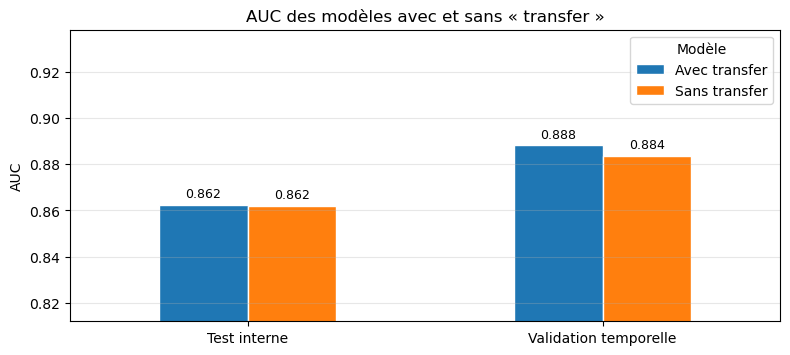

In [7]:
auc_plot = comparaison_focus[
    comparaison_focus["Seuil_standardise"] == "standard_0.5"
].copy()

# Si l'AUC est dupliquée par plusieurs seuils, on garde une seule ligne par modèle et par jeu.
auc_plot = auc_plot.drop_duplicates(["Modele_comparaison", "Jeu_standardise"])
auc_wide = auc_plot.pivot(index="Jeu_standardise", columns="Modele_comparaison", values="AUC")
auc_wide = auc_wide.reindex([j for j in jeux_focus if j in auc_wide.index])

fig, ax = plt.subplots(figsize=(8, 5))
auc_wide.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("AUC des modèles avec et sans « transfer »")
ax.set_xlabel("")
ax.set_ylabel("AUC")
ax.set_ylim(max(0.5, float(np.nanmin(auc_wide.values)) - 0.05), min(1.0, float(np.nanmax(auc_wide.values)) + 0.05))
ax.legend(title="Modèle")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.xticks(rotation=0, ha='center')
out_fig = FIG_DIR / "fig37_comparaison_auc.png"
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

#print(f"Figure sauvegardée : {out_fig}")

In [8]:
# ============================================================
# Localisation des fichiers de prédictions individuelles
# ============================================================

path_pred_avec = RESULT_DIR / "predictions_individuelles_avec_transfer.csv"
path_pred_sans = RESULT_DIR / "predictions_individuelles_sans_transfer.csv"

#print("Fichier avec transfer :", path_pred_avec.resolve())
#print("Fichier sans transfer :", path_pred_sans.resolve())

if not path_pred_avec.exists():
    raise FileNotFoundError(
        f"Fichier absent : {path_pred_avec.resolve()}\n"
        "Relancer le NB03 jusqu'à la cellule de sauvegarde des prédictions individuelles."
    )

if not path_pred_sans.exists():
    raise FileNotFoundError(
        f"Fichier absent : {path_pred_sans.resolve()}\n"
        "Relancer le NB04 jusqu'à la cellule de sauvegarde des prédictions individuelles."
    )

pred_avec = pd.read_csv(path_pred_avec)
pred_sans = pd.read_csv(path_pred_sans)

print("Prédictions avec transfer :", pred_avec.shape)
print("Prédictions sans transfer :", pred_sans.shape)

Prédictions avec transfer : (130476, 6)
Prédictions sans transfer : (130476, 6)


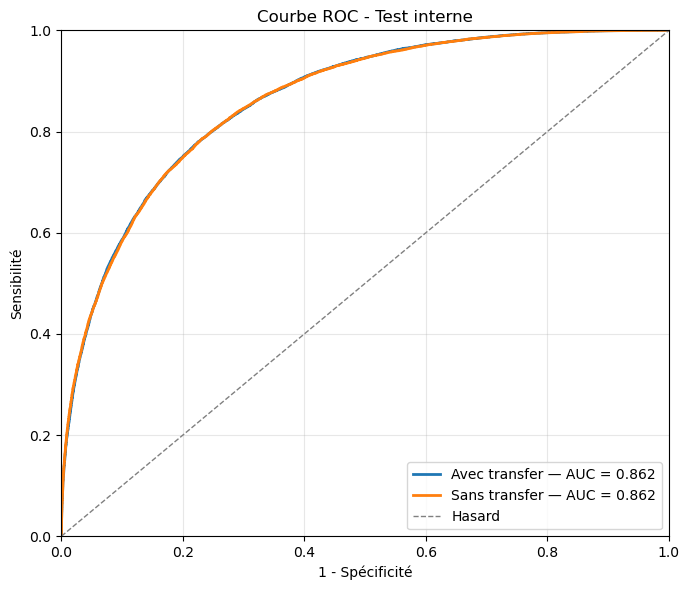

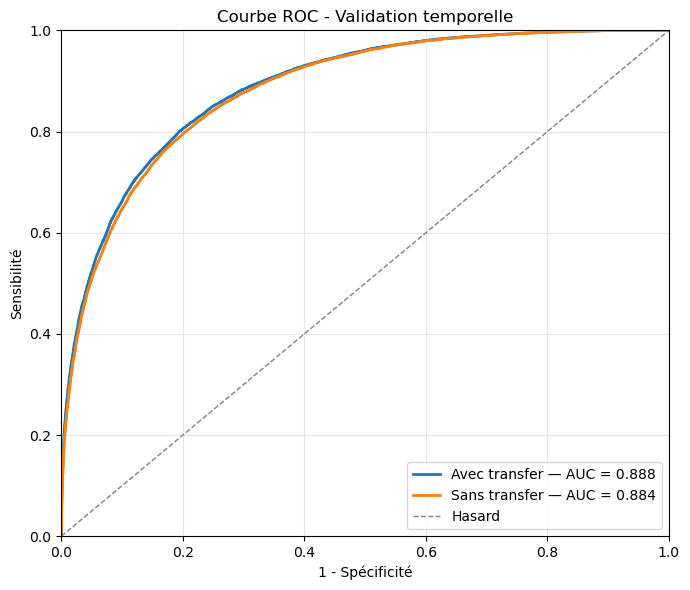

In [9]:
# ============================================================
# Courbe ROC — modèles avec et sans « transfer »
# ============================================================

pred_roc = pd.concat([pred_avec, pred_sans], ignore_index=True)

# Vérification des colonnes nécessaires.
required_cols = ["Modele_comparaison", "Jeu_standardise", "y_true", "y_proba"]
missing_cols = [c for c in required_cols if c not in pred_roc.columns]

if missing_cols:
    raise ValueError(
        f"Colonnes manquantes dans les fichiers de prédictions : {missing_cols}. "
        "Vérifier les cellules de sauvegarde dans les NB03 et NB04."
    )

# Nettoyage des types.
pred_roc["y_true"] = pd.to_numeric(pred_roc["y_true"], errors="coerce").astype("Int64")
pred_roc["y_proba"] = pd.to_numeric(pred_roc["y_proba"], errors="coerce")
pred_roc = pred_roc.dropna(subset=["y_true", "y_proba"]).copy()
pred_roc["y_true"] = pred_roc["y_true"].astype(int)

def slugify(text):
    text = str(text)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()
    return text

# La ROC utilise tous les seuils possibles : on ne filtre donc pas sur le seuil 0,5.
jeux_a_tracer = ["Test interne", "Validation temporelle"]

for jeu in jeux_a_tracer:
    data_jeu = pred_roc[pred_roc["Jeu_standardise"] == jeu].copy()

    if data_jeu.empty:
        print(f"Aucune donnée disponible pour : {jeu}")
        continue

    fig, ax = plt.subplots(figsize=(7, 6))

    for modele in data_jeu["Modele_comparaison"].dropna().unique():
        data_modele = data_jeu[data_jeu["Modele_comparaison"] == modele].copy()

        y_true = data_modele["y_true"].values
        y_proba = data_modele["y_proba"].values

        if len(np.unique(y_true)) < 2:
            print(f"ROC non calculable pour {modele} - {jeu} : une seule classe présente.")
            continue

        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value = roc_auc_score(y_true, y_proba)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{modele} — AUC = {auc_value:.3f}"
        )

    ax.plot(
        [0, 1], [0, 1],
        linestyle="--",
        linewidth=1,
        color="grey",
        label="Hasard"
    )

    ax.set_title(f"Courbe ROC - {jeu}")
    ax.set_xlabel("1 - Spécificité")
    ax.set_ylabel("Sensibilité")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

    plt.tight_layout()

    out_fig = FIG_DIR / f"fig38_roc_avec_sans_{slugify(jeu)}.png"
    plt.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()

    #print(f"Figure sauvegardée : {out_fig}")

## 8. Graphique 2: Sensibilité et spécificité en validation temporelle

Ce graphique compare les modèles au seuil clinique/alerte, c'est-à-dire dans la situation la plus proche de l'objectif opérationnel : anticiper l'hospitalisation pour réserver des lits.

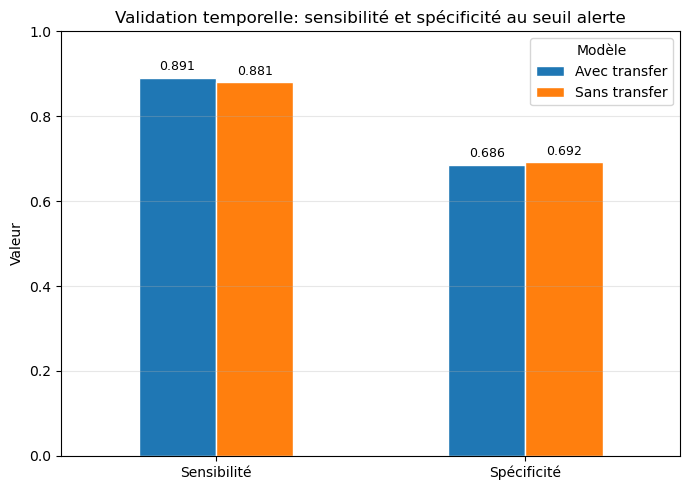

In [10]:
temp_clin = comparaison_focus[
    (comparaison_focus["Jeu_standardise"] == "Validation temporelle")
    & (comparaison_focus["Seuil_standardise"] == "seuil_alerte_Se90")
].copy()

temp_plot = temp_clin[["Modele_comparaison", "Se", "Sp"]].melt(
    id_vars="Modele_comparaison",
    value_vars=["Se", "Sp"],
    var_name="Métrique",
    value_name="Valeur"
)

temp_wide = temp_plot.pivot(index="Métrique", columns="Modele_comparaison", values="Valeur")
temp_wide = temp_wide.reindex(["Se", "Sp"])

def label_metric(x):
    return {"Se": "Sensibilité", "Sp": "Spécificité"}.get(x, x)

temp_wide.index = [label_metric(i) for i in temp_wide.index]

fig, ax = plt.subplots(figsize=(7, 5))
temp_wide.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Validation temporelle: sensibilité et spécificité au seuil alerte")
ax.set_xlabel("")
ax.set_ylabel("Valeur")
ax.set_ylim(0, 1)
ax.legend(title="Modèle")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
out_fig = FIG_DIR / "fig39_comparaison_se_sp_temp.png"
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

#print(f"Figure sauvegardée : {out_fig}")

## 9. Graphique 3 : Faux positifs et faux négatifs pour 100 passages

Ce graphique est utile pour l'interprétation opérationnelle :

- les **faux positifs** correspondent à des alertes de lit inutiles ;
- les **faux négatifs** correspondent à des hospitalisations non anticipées.

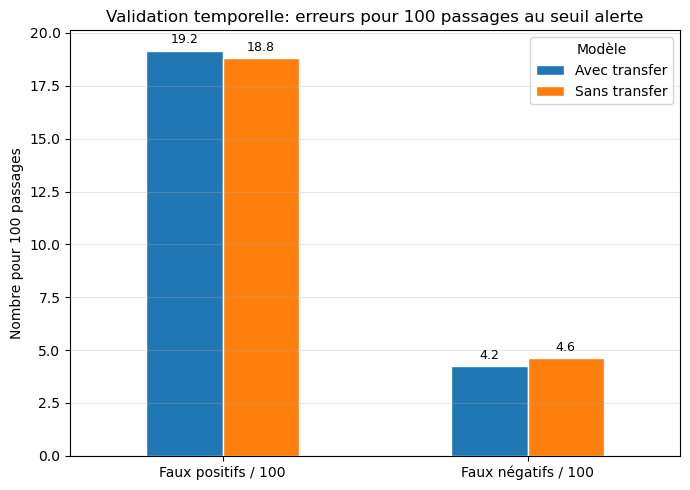

In [11]:
fpfn_cols = ["FP/100", "FN/100"]
if all(c in temp_clin.columns for c in fpfn_cols):
    fpfn_plot = temp_clin[["Modele_comparaison", "FP/100", "FN/100"]].melt(
        id_vars="Modele_comparaison",
        value_vars=fpfn_cols,
        var_name="Erreur",
        value_name="Pour 100 passages"
    )
    fpfn_wide = fpfn_plot.pivot(index="Erreur", columns="Modele_comparaison", values="Pour 100 passages")
    fpfn_wide = fpfn_wide.reindex(["FP/100", "FN/100"])
    fpfn_wide.index = ["Faux positifs / 100", "Faux négatifs / 100"]

    fig, ax = plt.subplots(figsize=(7, 5))
    fpfn_wide.plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_title("Validation temporelle: erreurs pour 100 passages au seuil alerte")
    ax.set_xlabel("")
    ax.set_ylabel("Nombre pour 100 passages")
    ax.legend(title="Modèle")
    ax.grid(axis="y", alpha=0.3)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
        
    plt.xticks(rotation = 0, ha='center')
    plt.tight_layout()
    out_fig = FIG_DIR / "fig40_comparaison_fp_fn_temp.png"
    plt.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()

    #print(f"Figure sauvegardée : {out_fig}")
else:
    print("Colonnes FP/100 et FN/100 indisponibles : graphique non généré.")

## 10. Section optionnelle version finale calibrée du modèle sans transfer

Cette section est conservée uniquement si un fichier `metrics_version_finale_sans_transfer.csv` est produit ultérieurement.  
Dans la version actuelle du pipeline, NB04 produit principalement :

- `metrics_meilleur_modele_sans_transfer.csv`
- `metrics_validation_temporelle_sans_transfer.csv`

La comparaison principale ci-dessus est donc la comparaison de référence.

In [12]:
path_final_sans = RESULT_DIR / "metrics_version_finale_sans_transfer.csv"

if path_final_sans.exists():
    metrics_sans_final = preparer_metrics(
        pd.read_csv(path_final_sans),
        "Sans transfer — version finale NB04",
        "NB04_metrics_version_finale_sans_transfer.csv"
    )
    display(metrics_sans_final[cols_affichage].round(4))
    metrics_sans_final.to_csv(RESULT_DIR / "tab38_comparaison_sans_version_finale.csv", index=False)
    print("Version finale sans transfer exportée : results/tab38_comparaison_sans_version_finale.csv")
else:
    print("Fichier metrics_version_finale_sans_transfer.csv non trouvé : section optionnelle ignorée.")

Fichier metrics_version_finale_sans_transfer.csv non trouvé : section optionnelle ignorée.


## 11. Résumé automatique pour la rédaction

In [13]:
def _get_value(df, modele, jeu, seuil, metric):
    m = df[
        (df["Modele_comparaison"] == modele)
        & (df["Jeu_standardise"] == jeu)
        & (df["Seuil_standardise"] == seuil)
    ]
    if m.empty or metric not in m.columns:
        return np.nan
    return float(m.iloc[0][metric])

auc_temp_avec = _get_value(comparaison_focus, "Avec transfer", "Validation temporelle", "standard_0.5", "AUC")
auc_temp_sans = _get_value(comparaison_focus, "Sans transfer", "Validation temporelle", "standard_0.5", "AUC")
se_temp_avec = _get_value(comparaison_focus, "Avec transfer", "Validation temporelle", "seuil_alerte_Se90", "Se")
sp_temp_avec = _get_value(comparaison_focus, "Avec transfer", "Validation temporelle", "seuil_alerte_Se90", "Sp")
se_temp_sans = _get_value(comparaison_focus, "Sans transfer", "Validation temporelle", "seuil_alerte_Se90", "Se")
sp_temp_sans = _get_value(comparaison_focus, "Sans transfer", "Validation temporelle", "seuil_alerte_Se90", "Sp")

delta_auc = auc_temp_avec - auc_temp_sans if not (np.isnan(auc_temp_avec) or np.isnan(auc_temp_sans)) else np.nan

resume = {
    "auc_validation_temporelle_avec_transfer": None if np.isnan(auc_temp_avec) else round(auc_temp_avec, 4),
    "auc_validation_temporelle_sans_transfer": None if np.isnan(auc_temp_sans) else round(auc_temp_sans, 4),
    "delta_auc_avec_moins_sans": None if np.isnan(delta_auc) else round(delta_auc, 4),
    "se_validation_temporelle_avec_transfer": None if np.isnan(se_temp_avec) else round(se_temp_avec, 4),
    "sp_validation_temporelle_avec_transfer": None if np.isnan(sp_temp_avec) else round(sp_temp_avec, 4),
    "se_validation_temporelle_sans_transfer": None if np.isnan(se_temp_sans) else round(se_temp_sans, 4),
    "sp_validation_temporelle_sans_transfer": None if np.isnan(sp_temp_sans) else round(sp_temp_sans, 4),
}

with open(RESULT_DIR / "resume_comparaison_avec_sans_transfer.json", "w", encoding="utf-8") as f:
    json.dump(resume, f, indent=2, ensure_ascii=False)

print("Résumé JSON sauvegardé : results/resume_comparaison_avec_sans_transfer.json")
print(json.dumps(resume, indent=2, ensure_ascii=False))

if not np.isnan(delta_auc):
    print(f"En résumé")
    print(
    f"En validation temporelle, le modèle avec le terme « transfer » obtient "
    f"une AUC de {auc_temp_avec:.3f}, contre {auc_temp_sans:.3f} pour le modèle "
    f"sans ce terme (ΔAUC = {delta_auc:+.3f}). "
    f"La comparaison indique l'apport opérationnel du terme « transfer » "
    f"lorsqu'il est disponible dès l'arrivée, tandis que le modèle sans transfer "
    f"sert d'analyse de sensibilité."
)


Résumé JSON sauvegardé : results/resume_comparaison_avec_sans_transfer.json
{
  "auc_validation_temporelle_avec_transfer": 0.8881,
  "auc_validation_temporelle_sans_transfer": 0.8836,
  "delta_auc_avec_moins_sans": 0.0045,
  "se_validation_temporelle_avec_transfer": 0.8911,
  "sp_validation_temporelle_avec_transfer": 0.6862,
  "se_validation_temporelle_sans_transfer": 0.8812,
  "sp_validation_temporelle_sans_transfer": 0.692
}
En résumé
En validation temporelle, le modèle avec le terme « transfer » obtient une AUC de 0.888, contre 0.884 pour le modèle sans ce terme (ΔAUC = +0.004). La comparaison indique l'apport opérationnel du terme « transfer » lorsqu'il est disponible dès l'arrivée, tandis que le modèle sans transfer sert d'analyse de sensibilité.


## 12. Conclusion méthodologique

Dans un objectif de **réservation anticipée de lits**, le modèle avec `transfer` peut être légitime si ce terme est présent dans le motif de consultation dès l'arrivée du patient aux urgences. Il correspond alors à une information précoce disponible pour l'outil opérationnel.

Le modèle sans `transfer` reste nécessaire comme **analyse de sensibilité**. Il vérifie que la performance ne dépend pas exclusivement d'un terme très associé à l'orientation hospitalière.